# Team 5 전력수요 예측 프로젝트: 확장 데이터 분석

> **분석 범위:** 패키지에 실제 포함된 2025-04-21 00:00~2025-04-24 23:00의 96시간 샘플  
> **핵심 질문:** 이 표본에서 확인되는 시간·기상 패턴은 무엇이며, 동일한 **day-ahead 24시간** 조건에서 단순 기준선들의 성능과 위험은 얼마나 안정적인가?  
> **중요한 경계:** 전체 학습 데이터와 `merged data.csv`, `best2.json`, 여러 원시·중간 파일이 없어 기존 XGBoost 성능은 재현할 수 없다.

이 노트북은 기존 `reproduce_analysis.py`의 단일 홀드아웃 분석을 확장한다. 데이터 지문과 품질계약, 시간대·일자·분포·피크·램프 분석, 기상관계의 민감도, 가능한 3개 순차 홀드아웃, 외삽 스트레스, 임시 의사결정 매트릭스를 한 번에 생성한다. 모든 표와 그림은 `analysis_outputs/`에 저장된다.

## 0. 재현 환경과 산출물 경로

- 노트북은 프로젝트 루트 또는 그 하위 한 단계에서 실행할 수 있다.
- 난수 시드는 42로 고정한다.
- 그래프 문구는 환경별 한글 글꼴 문제를 피하기 위해 영어를 사용하고, 해석은 Markdown으로 제공한다.

In [1]:
import os
import sys
import math
import hashlib
import platform
from pathlib import Path


def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "sample_data.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("sample_data.csv가 있는 프로젝트 루트를 찾지 못했습니다.")


ROOT = find_project_root()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / ".cache"))
(ROOT / ".mplconfig").mkdir(exist_ok=True)
(ROOT / ".cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
from IPython import get_ipython
from IPython.display import Markdown, display
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

get_ipython().run_line_magic("matplotlib", "inline")

SEED = 42
rng = np.random.default_rng(SEED)
DATA_PATH = ROOT / "sample_data.csv"
PACKAGED_COPY_PATH = ROOT / "강의 2강" / "team5" / "데이터 일체" / "data.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "font.family": "DejaVu Sans",
    }
)

environment_versions = pd.DataFrame(
    {
        "component": [
            "Python",
            "platform",
            "pandas",
            "numpy",
            "scipy",
            "scikit-learn",
            "matplotlib",
            "seaborn",
        ],
        "version": [
            sys.version.split()[0],
            platform.platform(),
            pd.__version__,
            np.__version__,
            scipy.__version__,
            sklearn.__version__,
            matplotlib.__version__,
            sns.__version__,
        ],
    }
)
environment_versions.to_csv(TABLE_DIR / "environment_versions.csv", index=False, encoding="utf-8-sig")
display(environment_versions)

,component,version
0,Python,3.11.4
1,platform,macOS-26.3.1-arm64-arm-64bit
2,pandas,3.0.3
3,numpy,2.4.6
4,scipy,1.17.1
5,scikit-learn,1.9.0
6,matplotlib,3.11.0
7,seaborn,0.13.2


## 1. 데이터 로드, 지문, 스키마 계약

CSV에는 헤더가 없으므로 열 순서를 명시적으로 고정한다. `demand`의 단위·배율과 타임스탬프 시간대는 패키지 자체만으로 확정할 수 없다. 따라서 수요 단위는 보고서 전체에서 **packaged unit**으로 쓴다.

In [2]:
COLS = ["datetime", "demand", "temperature", "wind_speed", "precipitation", "humidity"]
NUMERIC_COLS = COLS[1:]
WEATHER_COLS = COLS[2:]


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

raw = pd.read_csv(DATA_PATH, header=None)
if raw.shape[1] != len(COLS):
    raise ValueError(f"열 수가 {raw.shape[1]}개입니다. 예상 열 수는 {len(COLS)}개입니다.")

raw.columns = COLS
raw["datetime"] = pd.to_datetime(raw["datetime"], errors="raise")
for column in NUMERIC_COLS:
    raw[column] = pd.to_numeric(raw[column], errors="raise")

df = raw.sort_values("datetime").reset_index(drop=True).copy()
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()
df["is_weekend"] = df["datetime"].dt.dayofweek >= 5
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["ramp"] = df["demand"].diff()
df["abs_ramp"] = df["ramp"].abs()

fingerprint_rows = [
    {
        "file": str(DATA_PATH.relative_to(ROOT)),
        "bytes": DATA_PATH.stat().st_size,
        "sha256": sha256_file(DATA_PATH),
        "exists": True,
        "identical_to_primary": True,
    }
]

if PACKAGED_COPY_PATH.exists():
    copy_hash = sha256_file(PACKAGED_COPY_PATH)
    fingerprint_rows.append(
        {
            "file": str(PACKAGED_COPY_PATH.relative_to(ROOT)),
            "bytes": PACKAGED_COPY_PATH.stat().st_size,
            "sha256": copy_hash,
            "exists": True,
            "identical_to_primary": copy_hash == fingerprint_rows[0]["sha256"],
        }
    )

file_fingerprints = pd.DataFrame(fingerprint_rows)
file_fingerprints.to_csv(TABLE_DIR / "file_fingerprints.csv", index=False, encoding="utf-8-sig")

data_dictionary = pd.DataFrame(
    [
        ["datetime", "시간키", "datetime", "미확정(KST 추정)", "정시·중복·간격 검사"],
        ["demand", "예측표적", "integer", "packaged unit(원 단위 미확정)", "비음수·원천 lineage 필요"],
        ["temperature", "기상설명변수", "float", "°C로 추정", "물리범위·원천 확인"],
        ["wind_speed", "기상설명변수", "float", "m/s로 추정", "0 이상"],
        ["precipitation", "기상설명변수", "float", "mm로 추정", "0 이상·0 과다 분포"],
        ["humidity", "기상설명변수", "float", "%로 추정", "0~100"],
    ],
    columns=["variable", "role", "dtype", "unit_status", "validation"],
)
data_dictionary.to_csv(TABLE_DIR / "data_dictionary.csv", index=False, encoding="utf-8-sig")

display(file_fingerprints)
display(data_dictionary)

,file,bytes,sha256,exists,identical_to_primary
0,sample_data.csv,4695,fb214f92f1ea57ff0f5ce5f64f6be61ee139f2d89f1041...,True,True
1,강의 2강/team5/데이터 일체/data.csv,4695,fb214f92f1ea57ff0f5ce5f64f6be61ee139f2d89f1041...,True,True


,variable,role,dtype,unit_status,validation
0,datetime,시간키,datetime,미확정(KST 추정),정시·중복·간격 검사
1,demand,예측표적,integer,packaged unit(원 단위 미확정),비음수·원천 lineage 필요
2,temperature,기상설명변수,float,°C로 추정,물리범위·원천 확인
3,wind_speed,기상설명변수,float,m/s로 추정,0 이상
4,precipitation,기상설명변수,float,mm로 추정,0 이상·0 과다 분포
5,humidity,기상설명변수,float,%로 추정,0~100


### 해석

`sample_data.csv`와 원 팀 폴더의 `data.csv`가 같은 SHA-256이면 두 번째 파일은 추가 학습자료가 아니라 **동일한 96시간 복제본**이다. 파일명이 `data.csv`라고 해서 전체 데이터로 간주하면 안 된다.

## 2. 데이터 품질과 표본 커버리지

최종 파일에 결측이 없더라도 upstream 코드가 기상 결측을 0으로 치환했기 때문에 원시자료의 완전성을 뜻하지 않는다. 여기서는 최종 패키지 수준에서 확인 가능한 사실만 검사한다.

In [3]:
expected_index = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
missing_timestamps = expected_index.difference(pd.DatetimeIndex(df["datetime"]))
time_diffs = df["datetime"].diff().dropna()

quality_checks = pd.DataFrame(
    [
        ["row_count", len(df), 96, len(df) == 96],
        ["start_timestamp", str(df["datetime"].min()), "2025-04-21 00:00:00", str(df["datetime"].min()) == "2025-04-21 00:00:00"],
        ["end_timestamp", str(df["datetime"].max()), "2025-04-24 23:00:00", str(df["datetime"].max()) == "2025-04-24 23:00:00"],
        ["expected_hour_count", len(expected_index), 96, len(expected_index) == 96],
        ["missing_cell_count", int(df[COLS].isna().sum().sum()), 0, int(df[COLS].isna().sum().sum()) == 0],
        ["infinite_numeric_count", int(np.isinf(df[NUMERIC_COLS].to_numpy(dtype=float)).sum()), 0, int(np.isinf(df[NUMERIC_COLS].to_numpy(dtype=float)).sum()) == 0],
        ["duplicate_row_count", int(df[COLS].duplicated().sum()), 0, int(df[COLS].duplicated().sum()) == 0],
        ["duplicate_timestamp_count", int(df["datetime"].duplicated().sum()), 0, int(df["datetime"].duplicated().sum()) == 0],
        ["missing_timestamp_count", len(missing_timestamps), 0, len(missing_timestamps) == 0],
        ["non_hourly_gap_count", int((time_diffs != pd.Timedelta(hours=1)).sum()), 0, int((time_diffs != pd.Timedelta(hours=1)).sum()) == 0],
        ["negative_demand_count", int((df["demand"] < 0).sum()), 0, int((df["demand"] < 0).sum()) == 0],
        ["negative_wind_count", int((df["wind_speed"] < 0).sum()), 0, int((df["wind_speed"] < 0).sum()) == 0],
        ["negative_precipitation_count", int((df["precipitation"] < 0).sum()), 0, int((df["precipitation"] < 0).sum()) == 0],
        ["humidity_outside_0_100_count", int((~df["humidity"].between(0, 100)).sum()), 0, int((~df["humidity"].between(0, 100)).sum()) == 0],
    ],
    columns=["check", "observed", "expected", "passed"],
)

total_precipitation = float(df["precipitation"].sum())
daily_precipitation = df.groupby("date")["precipitation"].sum()
max_day_precipitation_share = (
    float(daily_precipitation.max() / total_precipitation * 100) if total_precipitation > 0 else np.nan
)

coverage_summary = pd.DataFrame(
    [
        ["observed_hours", len(df)],
        ["calendar_days", df["date"].nunique()],
        ["months", df["datetime"].dt.to_period("M").nunique()],
        ["unique_weekdays", df["weekday"].nunique()],
        ["weekend_hours", int(df["is_weekend"].sum())],
        ["hours_with_precipitation_gt_0", int((df["precipitation"] > 0).sum())],
        ["hours_with_precipitation_ge_1", int((df["precipitation"] >= 1).sum())],
        ["total_precipitation", total_precipitation],
        ["max_single_day_precipitation_share_pct", max_day_precipitation_share],
    ],
    columns=["coverage_item", "value"],
)

quality_checks.to_csv(TABLE_DIR / "data_quality_checks.csv", index=False, encoding="utf-8-sig")
coverage_summary.to_csv(TABLE_DIR / "coverage_summary.csv", index=False, encoding="utf-8-sig")

display(quality_checks)
display(coverage_summary)

,check,observed,expected,passed
0,row_count,96,96,True
1,start_timestamp,2025-04-21 00:00:00,2025-04-21 00:00:00,True
2,end_timestamp,2025-04-24 23:00:00,2025-04-24 23:00:00,True
3,expected_hour_count,96,96,True
4,missing_cell_count,0,0,True
5,infinite_numeric_count,0,0,True
6,duplicate_row_count,0,0,True
7,duplicate_timestamp_count,0,0,True
8,missing_timestamp_count,0,0,True
9,non_hourly_gap_count,0,0,True


,coverage_item,value
0,observed_hours,96.000000
1,calendar_days,4.000000
2,months,1.000000
3,unique_weekdays,4.000000
4,weekend_hours,0.000000
5,hours_with_precipitation_gt_0,32.000000
6,hours_with_precipitation_ge_1,11.000000
7,total_precipitation,27.200000
8,max_single_day_precipitation_share_pct,99.485294


### 품질 판정

- 최종 샘플은 96개 정시 관측으로 구성되고 결측·중복·시간누락이 없다.
- 그러나 표본은 월~목 4일뿐이며 주말·휴일·계절 변화가 없다. 날짜와 요일이 1:1로 겹치므로 요일효과와 날짜효과를 분리할 수 없다.
- 강수량 대부분이 하루에 집중되면 강수와 수요의 상관은 사실상 **한 날짜의 수준차이**를 반영할 수 있다.

## 3. 기술통계, 일별·시간대별 부하, 피크와 램프

단순 평균에 그치지 않고 분포, 날짜 간 수준차이, 하루 안의 부하곡선, 상위 수요시간과 시간당 변화량을 함께 본다.

In [4]:
descriptive = df[NUMERIC_COLS].describe(percentiles=[0.25, 0.5, 0.75]).T
descriptive = descriptive.rename(columns={"25%": "q1", "50%": "median", "75%": "q3"})
descriptive["cv_pct"] = descriptive["std"] / descriptive["mean"].replace(0, np.nan) * 100
descriptive["zero_share_pct"] = [(df[column] == 0).mean() * 100 for column in descriptive.index]

iqr_outlier_counts = []
for column in descriptive.index:
    q1 = descriptive.loc[column, "q1"]
    q3 = descriptive.loc[column, "q3"]
    iqr = q3 - q1
    mask = (df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr)
    iqr_outlier_counts.append(int(mask.sum()))
descriptive["iqr_flag_count"] = iqr_outlier_counts
descriptive = descriptive.reset_index(names="variable")

daily_rows = []
for date_value, group in df.groupby("date", sort=True):
    peak_idx = group["demand"].idxmax()
    trough_idx = group["demand"].idxmin()
    daily_rows.append(
        {
            "date": str(date_value),
            "weekday": group["weekday"].iloc[0],
            "demand_mean": group["demand"].mean(),
            "demand_min": group["demand"].min(),
            "demand_max": group["demand"].max(),
            "load_factor_mean_over_max": group["demand"].mean() / group["demand"].max(),
            "peak_hour": int(df.loc[peak_idx, "hour"]),
            "trough_hour": int(df.loc[trough_idx, "hour"]),
            "temperature_mean": group["temperature"].mean(),
            "precipitation_sum": group["precipitation"].sum(),
            "humidity_mean": group["humidity"].mean(),
        }
    )
daily_summary = pd.DataFrame(daily_rows)

hourly_profile = (
    df.groupby("hour")["demand"]
    .agg(mean="mean", std="std", min="min", q10=lambda x: x.quantile(0.10), median="median", q90=lambda x: x.quantile(0.90), max="max")
    .reset_index()
)

peak_threshold = df["demand"].quantile(0.90)
peak_hours = df.loc[df["demand"] >= peak_threshold, ["datetime", "date", "hour", "demand", "precipitation", "humidity"]].copy()
peak_hours["threshold_p90"] = peak_threshold

valid_ramps = df.dropna(subset=["ramp"]).copy()
max_up_idx = valid_ramps["ramp"].idxmax()
max_down_idx = valid_ramps["ramp"].idxmin()
ramp_summary = pd.DataFrame(
    [
        {
            "absolute_ramp_mean": valid_ramps["abs_ramp"].mean(),
            "absolute_ramp_median": valid_ramps["abs_ramp"].median(),
            "absolute_ramp_p90": valid_ramps["abs_ramp"].quantile(0.90),
            "max_up_ramp": valid_ramps.loc[max_up_idx, "ramp"],
            "max_up_timestamp": str(valid_ramps.loc[max_up_idx, "datetime"]),
            "max_down_ramp": valid_ramps.loc[max_down_idx, "ramp"],
            "max_down_timestamp": str(valid_ramps.loc[max_down_idx, "datetime"]),
        }
    ]
)

descriptive.to_csv(TABLE_DIR / "descriptive_statistics.csv", index=False, encoding="utf-8-sig")
daily_summary.to_csv(TABLE_DIR / "daily_summary.csv", index=False, encoding="utf-8-sig")
hourly_profile.to_csv(TABLE_DIR / "hourly_profile.csv", index=False, encoding="utf-8-sig")
peak_hours.to_csv(TABLE_DIR / "peak_hours.csv", index=False, encoding="utf-8-sig")
ramp_summary.to_csv(TABLE_DIR / "ramp_summary.csv", index=False, encoding="utf-8-sig")

display(descriptive.round(3))
display(daily_summary.round(3))
display(ramp_summary.round(3))

,variable,count,mean,std,min,q1,median,q3,max,cv_pct,zero_share_pct,iqr_flag_count
0,demand,96.0,713455.219,70128.819,571137.00,657920.500,705141.000,768540.250,835946.00,9.829,0.000,0
1,temperature,96.0,15.362,3.120,9.75,12.795,15.310,17.065,22.48,20.309,0.000,0
2,wind_speed,96.0,2.148,0.728,1.16,1.570,2.035,2.518,3.95,33.902,0.000,1
3,precipitation,96.0,0.283,0.708,0.00,0.000,0.000,0.020,2.80,249.744,66.667,20
4,humidity,96.0,77.795,16.873,44.57,62.798,85.905,91.650,95.50,21.689,0.000,0


,date,weekday,demand_mean,demand_min,demand_max,load_factor_mean_over_max,peak_hour,trough_hour,temperature_mean,precipitation_sum,humidity_mean
0,2025-04-21,Monday,686925.875,571137,813385,0.845,19,3,16.912,0.01,74.532
1,2025-04-22,Tuesday,760111.333,633733,835946,0.909,10,3,15.587,27.06,92.633
2,2025-04-23,Wednesday,712465.542,641837,805656,0.884,19,3,14.593,0.13,78.664
3,2025-04-24,Thursday,694318.125,602792,801394,0.866,19,12,14.356,0.00,65.349


,absolute_ramp_mean,absolute_ramp_median,absolute_ramp_p90,max_up_ramp,max_up_timestamp,max_down_ramp,max_down_timestamp
0,21219.905,22594.0,33367.8,58849.0,2025-04-22 07:00:00,-47952.0,2025-04-23 00:00:00


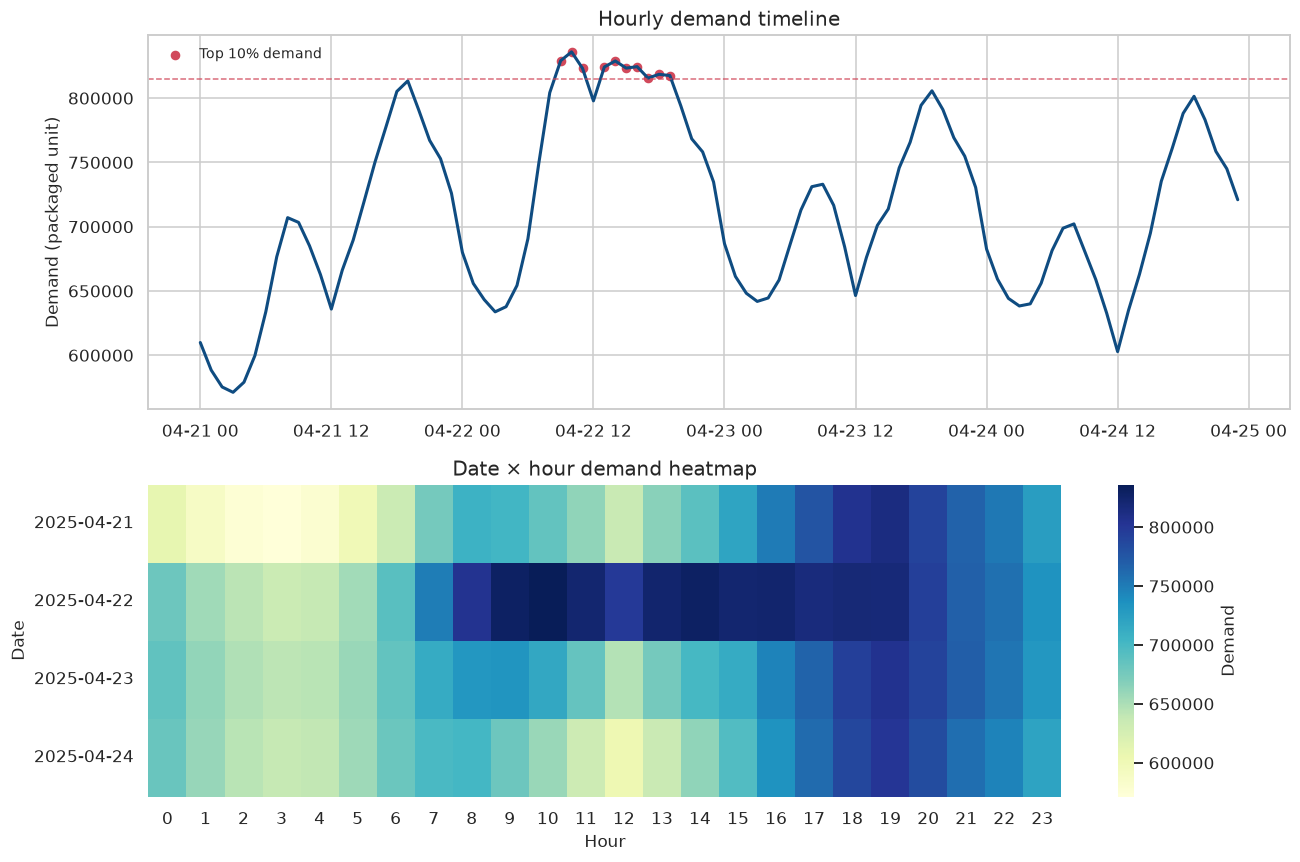

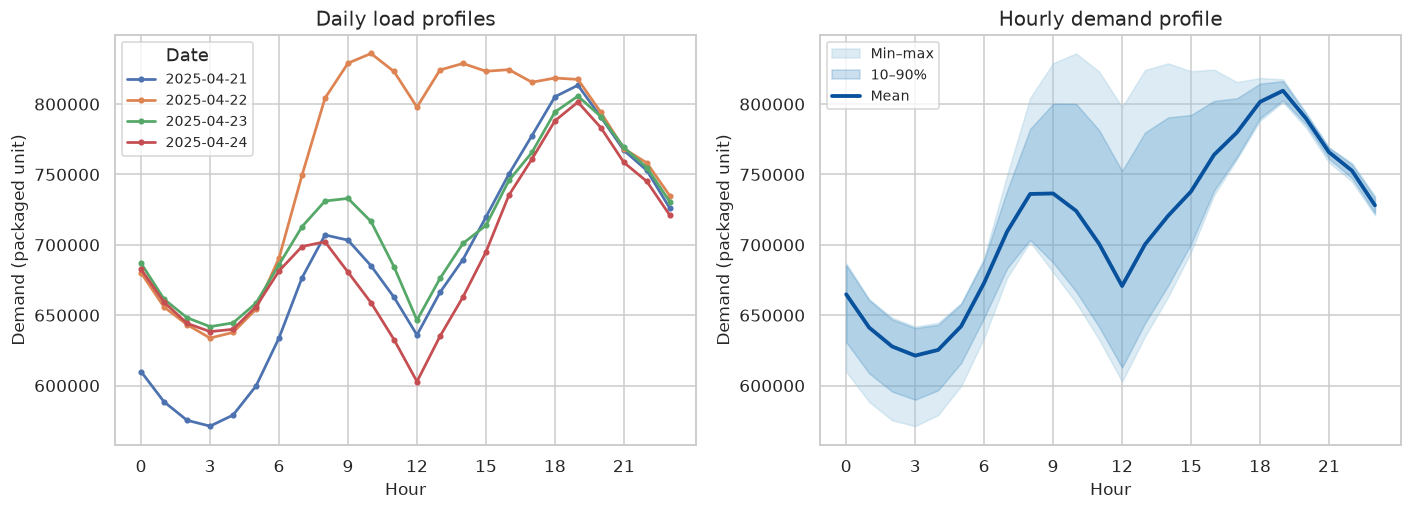

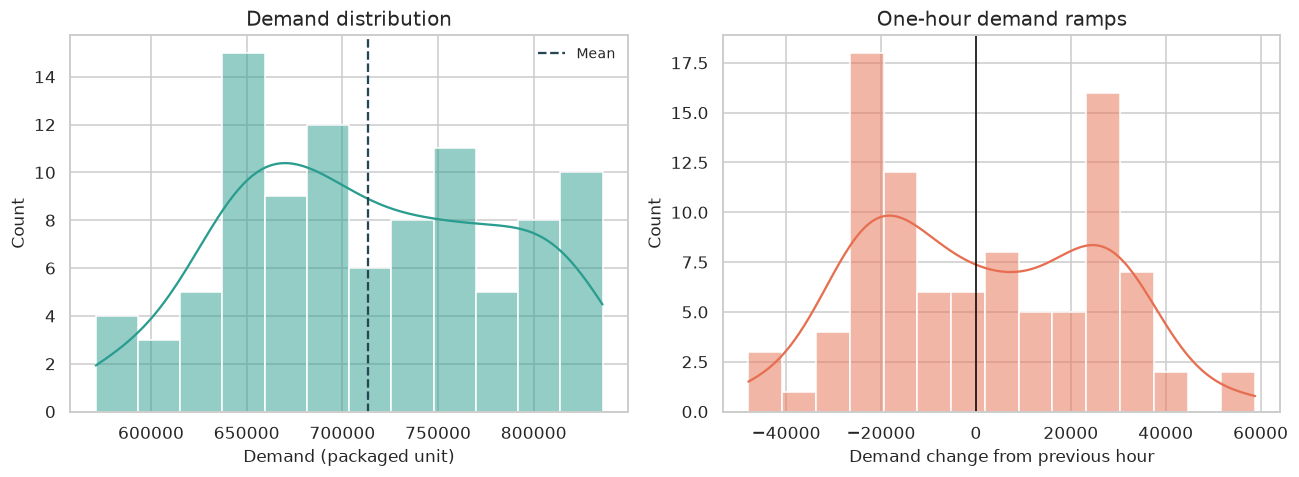

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1.2, 1]})
axes[0].plot(df["datetime"], df["demand"], color="#0f4c81", linewidth=2)
axes[0].scatter(peak_hours["datetime"], peak_hours["demand"], color="#d1495b", s=28, label="Top 10% demand")
axes[0].axhline(peak_threshold, color="#d1495b", linestyle="--", linewidth=1, alpha=0.8)
axes[0].set(title="Hourly demand timeline", ylabel="Demand (packaged unit)")
axes[0].legend(loc="upper left")

demand_matrix = df.pivot(index="date", columns="hour", values="demand")
sns.heatmap(demand_matrix, cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Demand"})
axes[1].set(title="Date × hour demand heatmap", xlabel="Hour", ylabel="Date")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_demand_timeline_heatmap.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for date_value, group in df.groupby("date", sort=True):
    axes[0].plot(group["hour"], group["demand"], marker="o", markersize=3, linewidth=1.8, label=str(date_value))
axes[0].set(title="Daily load profiles", xlabel="Hour", ylabel="Demand (packaged unit)", xticks=range(0, 24, 3))
axes[0].legend(title="Date", frameon=True)

x_hours = hourly_profile["hour"].to_numpy(dtype=float)
mean_demand = hourly_profile["mean"].to_numpy(dtype=float)
min_demand = hourly_profile["min"].to_numpy(dtype=float)
max_demand = hourly_profile["max"].to_numpy(dtype=float)
q10_demand = hourly_profile["q10"].to_numpy(dtype=float)
q90_demand = hourly_profile["q90"].to_numpy(dtype=float)
axes[1].fill_between(x_hours, min_demand, max_demand, color="#9ecae1", alpha=0.35, label="Min–max")
axes[1].fill_between(x_hours, q10_demand, q90_demand, color="#3182bd", alpha=0.25, label="10–90%")
axes[1].plot(x_hours, mean_demand, color="#08519c", linewidth=2.5, label="Mean")
axes[1].set(title="Hourly demand profile", xlabel="Hour", ylabel="Demand (packaged unit)", xticks=range(0, 24, 3))
axes[1].legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_daily_and_hourly_profiles.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["demand"], bins=12, kde=True, color="#2a9d8f", ax=axes[0])
axes[0].axvline(df["demand"].mean(), color="#264653", linestyle="--", label="Mean")
axes[0].set(title="Demand distribution", xlabel="Demand (packaged unit)")
axes[0].legend()
sns.histplot(valid_ramps["ramp"], bins=15, kde=True, color="#e76f51", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="One-hour demand ramps", xlabel="Demand change from previous hour")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_distribution_and_ramps.png", bbox_inches="tight")
plt.show()

### 해석 포인트

- 날짜별 수준차이와 하루 안의 반복 패턴이 동시에 존재한다.
- 평균 시간대 곡선은 03시 부근이 낮고 19시 부근이 높다. 다만 시간대별 관측은 4개뿐이다.
- 피크시간과 급격한 램프는 평균오차가 감추는 운영위험이므로 이후 모델 비교에서 별도 지표로 사용한다.

## 4. 기상변수 관계: 원상관과 교란 민감도

상관계수는 인과효과가 아니다. 이 표본에서는 강수가 한 날짜에 집중되고 시간대 패턴도 강하므로, 원상관·날짜평균 제거·시간대평균 제거·날짜와 시간대 동시 제거 결과가 얼마나 달라지는지 비교한다. 일반적인 p-value는 시간자기상관과 4개 날짜 군집을 무시하므로 결론 근거로 사용하지 않는다.

In [6]:
def safe_pearson(x: pd.Series, y: pd.Series) -> float:
    valid = pd.concat([x, y], axis=1).dropna()
    if len(valid) < 3 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pearsonr(valid.iloc[:, 0], valid.iloc[:, 1]).statistic)


def safe_spearman(x: pd.Series, y: pd.Series) -> float:
    valid = pd.concat([x, y], axis=1).dropna()
    if len(valid) < 3 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(spearmanr(valid.iloc[:, 0], valid.iloc[:, 1]).statistic)


correlation_rows = []
for weather in WEATHER_COLS:
    demand_date_residual = df["demand"] - df.groupby("date")["demand"].transform("mean")
    weather_date_residual = df[weather] - df.groupby("date")[weather].transform("mean")
    demand_hour_residual = df["demand"] - df.groupby("hour")["demand"].transform("mean")
    weather_hour_residual = df[weather] - df.groupby("hour")[weather].transform("mean")
    demand_two_way = (
        df["demand"]
        - df.groupby("date")["demand"].transform("mean")
        - df.groupby("hour")["demand"].transform("mean")
        + df["demand"].mean()
    )
    weather_two_way = (
        df[weather]
        - df.groupby("date")[weather].transform("mean")
        - df.groupby("hour")[weather].transform("mean")
        + df[weather].mean()
    )
    correlation_rows.extend(
        [
            [weather, "raw_pearson", safe_pearson(df["demand"], df[weather])],
            [weather, "raw_spearman", safe_spearman(df["demand"], df[weather])],
            [weather, "within_date_pearson", safe_pearson(demand_date_residual, weather_date_residual)],
            [weather, "within_hour_pearson", safe_pearson(demand_hour_residual, weather_hour_residual)],
            [weather, "two_way_demeaned_pearson", safe_pearson(demand_two_way, weather_two_way)],
        ]
    )

weather_correlation_sensitivity = pd.DataFrame(correlation_rows, columns=["weather_variable", "method", "correlation"])

daily_correlation_rows = []
for date_value, group in df.groupby("date", sort=True):
    for weather in WEATHER_COLS:
        daily_correlation_rows.append(
            {
                "date": str(date_value),
                "weather_variable": weather,
                "pearson_r": safe_pearson(group["demand"], group[weather]),
                "n": len(group),
            }
        )
daily_weather_correlations = pd.DataFrame(daily_correlation_rows)

vif_rows = []
for target_feature in WEATHER_COLS:
    other_features = [feature for feature in WEATHER_COLS if feature != target_feature]
    vif_model = LinearRegression().fit(df[other_features], df[target_feature])
    r2 = vif_model.score(df[other_features], df[target_feature])
    vif_rows.append([target_feature, r2, 1 / (1 - r2) if r2 < 1 else np.inf])
weather_vif = pd.DataFrame(vif_rows, columns=["weather_variable", "r2_from_other_weather", "vif"])

wet_dry_summary = (
    df.assign(period=np.where(df["precipitation"] > 0, "wet_hour", "dry_hour"))
    .groupby("period")
    .agg(n=("demand", "size"), demand_mean=("demand", "mean"), demand_median=("demand", "median"), precipitation_sum=("precipitation", "sum"))
    .reset_index()
)

weather_correlation_sensitivity.to_csv(TABLE_DIR / "weather_correlation_sensitivity.csv", index=False, encoding="utf-8-sig")
daily_weather_correlations.to_csv(TABLE_DIR / "daily_weather_correlations.csv", index=False, encoding="utf-8-sig")
weather_vif.to_csv(TABLE_DIR / "weather_vif.csv", index=False, encoding="utf-8-sig")
wet_dry_summary.to_csv(TABLE_DIR / "wet_dry_summary.csv", index=False, encoding="utf-8-sig")

display(weather_correlation_sensitivity.pivot(index="weather_variable", columns="method", values="correlation").round(3))
display(daily_weather_correlations.pivot(index="date", columns="weather_variable", values="pearson_r").round(3))
display(weather_vif.round(3))
display(wet_dry_summary.round(3))

method,raw_pearson,raw_spearman,two_way_demeaned_pearson,within_date_pearson,within_hour_pearson
weather_variable,,,,,
humidity,-0.011,0.121,0.435,-0.309,0.673
precipitation,0.484,0.292,0.751,0.329,0.850
temperature,0.276,0.312,-0.354,0.333,-0.244
wind_speed,0.241,0.306,-0.108,0.366,-0.242


weather_variable,humidity,precipitation,temperature,wind_speed
date,,,,
2025-04-21,-0.540,-0.275,0.614,0.432
2025-04-22,0.932,0.585,0.566,0.779
2025-04-23,-0.364,-0.613,0.205,-0.179
2025-04-24,-0.491,NaN,0.102,0.492


,weather_variable,r2_from_other_weather,vif
0,temperature,0.490,1.963
1,wind_speed,0.792,4.810
2,precipitation,0.480,1.925
3,humidity,0.838,6.158


,period,n,demand_mean,demand_median,precipitation_sum
0,dry_hour,64,703227.672,701537.5,0.0
1,wet_hour,32,733910.312,742097.5,27.2


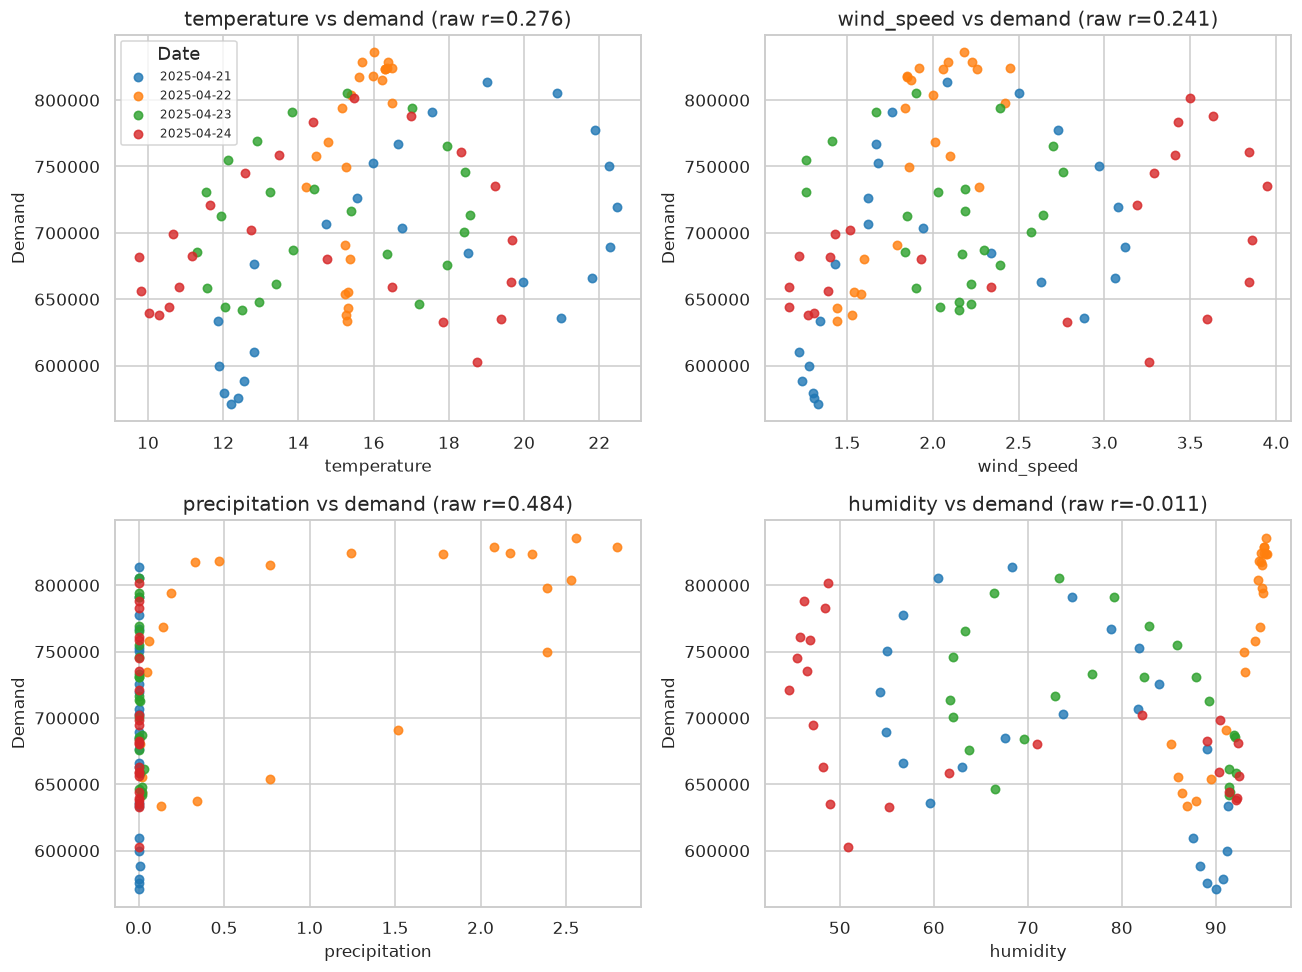

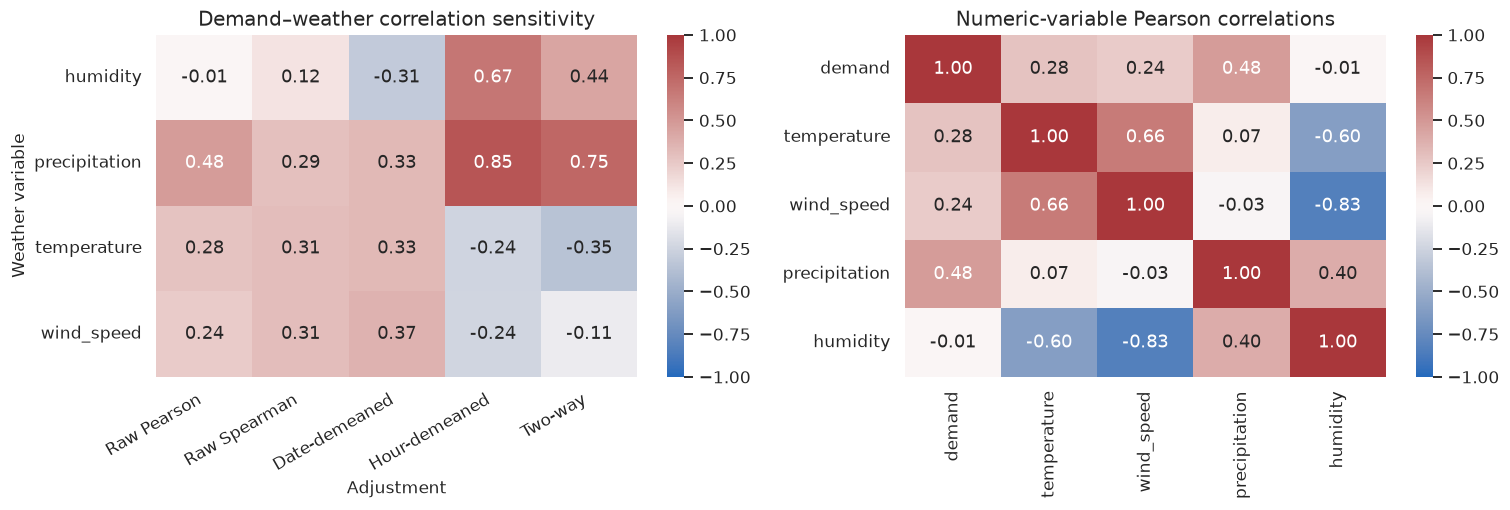

In [7]:
palette = dict(zip(sorted(df["date"].astype(str).unique()), sns.color_palette("tab10", n_colors=df["date"].nunique())))
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, weather in zip(axes.flat, WEATHER_COLS):
    for date_value, group in df.groupby(df["date"].astype(str), sort=True):
        ax.scatter(group[weather], group["demand"], s=30, alpha=0.8, label=date_value, color=palette[date_value])
    raw_r = safe_pearson(df["demand"], df[weather])
    ax.set(title=f"{weather} vs demand (raw r={raw_r:.3f})", xlabel=weather, ylabel="Demand")
axes[0, 0].legend(title="Date", fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_weather_scatter_by_date.png", bbox_inches="tight")
plt.show()

corr_matrix = weather_correlation_sensitivity.pivot(index="weather_variable", columns="method", values="correlation")
ordered_methods = ["raw_pearson", "raw_spearman", "within_date_pearson", "within_hour_pearson", "two_way_demeaned_pearson"]
corr_matrix = corr_matrix[ordered_methods]
corr_matrix = corr_matrix.rename(
    columns={
        "raw_pearson": "Raw Pearson",
        "raw_spearman": "Raw Spearman",
        "within_date_pearson": "Date-demeaned",
        "within_hour_pearson": "Hour-demeaned",
        "two_way_demeaned_pearson": "Two-way",
    }
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", center=0, cmap="vlag", vmin=-1, vmax=1, ax=axes[0])
axes[0].set(title="Demand–weather correlation sensitivity", xlabel="Adjustment", ylabel="Weather variable")
axes[0].tick_params(axis="x", rotation=30)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("right")
predictor_corr = df[NUMERIC_COLS].corr()
sns.heatmap(predictor_corr, annot=True, fmt=".2f", center=0, cmap="vlag", vmin=-1, vmax=1, ax=axes[1])
axes[1].set(title="Numeric-variable Pearson correlations")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_correlation_sensitivity.png", bbox_inches="tight")
plt.show()

### 해석 포인트

- 원자료의 강수–수요 상관이 크더라도 강수 자체의 효과라고 말할 수 없다.
- 날짜/시간대 평균을 제거하는 방식에 따라 방향과 크기가 달라지면 변수선택의 근거로 단순 상관을 쓰기 어렵다.
- 비가 온 시간과 마른 시간의 평균차이도 강우시간이 특정 날짜·시간대에 몰려 있으므로 기술통계일 뿐이다.
- 풍속·습도 등 기상변수끼리도 강하게 연관될 수 있어 단변량 상관을 독립효과처럼 해석하면 안 된다.

## 5. 시간의존성: 자기상관과 예측가능성

전력수요는 연속 시간자료이므로 관측 96개를 독립 표본처럼 취급할 수 없다. lag가 길수록 유효한 쌍의 수도 줄어든다.

,lag_hours,autocorrelation,pair_count
0,1,0.939,95
1,2,0.790,94
2,3,0.589,93
5,6,0.009,90
11,12,-0.141,84
23,24,0.509,72
47,48,0.496,48
71,72,0.874,24


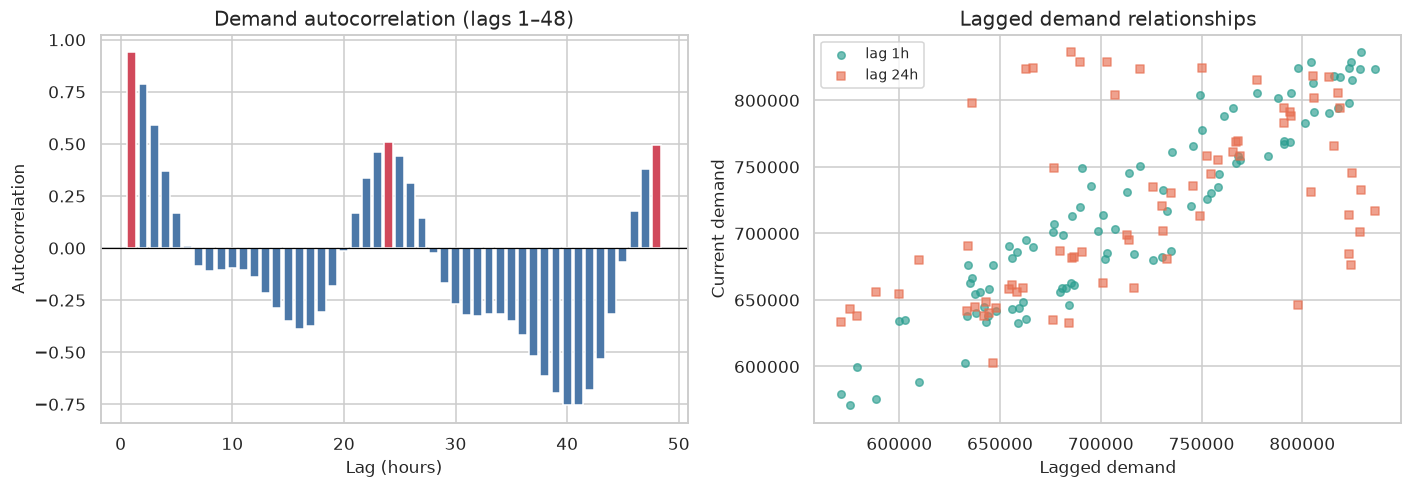

In [8]:
autocorrelation = pd.DataFrame(
    {
        "lag_hours": np.arange(1, 73),
        "autocorrelation": [df["demand"].autocorr(lag=lag) for lag in range(1, 73)],
        "pair_count": [len(df) - lag for lag in range(1, 73)],
    }
)
autocorrelation.to_csv(TABLE_DIR / "demand_autocorrelation.csv", index=False, encoding="utf-8-sig")

display(autocorrelation.loc[autocorrelation["lag_hours"].isin([1, 2, 3, 6, 12, 24, 48, 72])].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
acf48 = autocorrelation[autocorrelation["lag_hours"] <= 48]
colors = np.where(acf48["lag_hours"].isin([1, 24, 48]), "#d1495b", "#4c78a8")
axes[0].bar(acf48["lag_hours"], acf48["autocorrelation"], color=colors, width=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Demand autocorrelation (lags 1–48)", xlabel="Lag (hours)", ylabel="Autocorrelation")

for lag, marker, color in [(1, "o", "#2a9d8f"), (24, "s", "#e76f51")]:
    x = df["demand"].shift(lag)
    valid = x.notna()
    axes[1].scatter(x[valid], df.loc[valid, "demand"], s=24, alpha=0.65, marker=marker, color=color, label=f"lag {lag}h")
axes[1].set(title="Lagged demand relationships", xlabel="Lagged demand", ylabel="Current demand")
axes[1].legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_autocorrelation_and_lags.png", bbox_inches="tight")
plt.show()

## 6. 동일 조건의 24시간 day-ahead 백테스트

### 평가 규칙

1. 첫날 이후 가능한 세 날짜(4/22, 4/23, 4/24)를 각각 24시간 test fold로 둔다.
2. 각 fold는 해당 날짜가 시작되기 직전 자료만 학습에 사용한다.
3. 모든 후보가 하루 24개 값을 한 번에 예측하도록 맞춘다.
4. 실제 미래 관측기상을 사용하는 Ridge는 운영 가능한 모델이 아니라 **oracle/스트레스 실험**으로 분리한다.
5. sMAPE, MAE, RMSE, WAPE, 편향, 과소예측률, 상위 10% 피크 MAE, 음수예측을 함께 본다.

`1시간 지속성(rolling one-step)`은 매시간 실제 직전수요를 새로 받으므로 이 day-ahead 순위표에 넣지 않는다.

In [9]:
MODEL_LABELS = {
    "block_persistence_24h": "24h block persistence",
    "seasonal_naive_24h": "24h seasonal naive",
    "past_same_hour_mean": "Past same-hour mean",
    "ridge_calendar": "Ridge calendar",
    "ridge_calendar_weather_oracle": "Ridge calendar + observed weather (oracle)",
}


def forecast_metrics(y_true, y_pred, peak_quantile=0.90):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    smape_terms = np.where(denominator == 0, 0.0, 2 * np.abs(y_true - y_pred) / denominator)
    peak_mask = y_true >= np.quantile(y_true, peak_quantile)
    return {
        "n": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "wape_pct": np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100 if np.abs(y_true).sum() else np.nan,
        "smape_pct": smape_terms.mean() * 100,
        "r2": r2_score(y_true, y_pred),
        "bias_prediction_minus_actual": np.mean(y_pred - y_true),
        "underprediction_rate_pct": np.mean(y_pred < y_true) * 100,
        "peak_mae": np.abs(y_true[peak_mask] - y_pred[peak_mask]).mean(),
        "negative_prediction_count": int((y_pred < 0).sum()),
    }


fold_rows = []
prediction_rows = []
fold_origins = [24, 48, 72]
calendar_features = ["hour_sin", "hour_cos"]
oracle_features = calendar_features + WEATHER_COLS

for fold_number, origin in enumerate(fold_origins, start=1):
    train = df.iloc[:origin].copy()
    test = df.iloc[origin : origin + 24].copy()
    forecasts = {
        "block_persistence_24h": np.repeat(train["demand"].iloc[-1], len(test)),
        "seasonal_naive_24h": df["demand"].shift(24).iloc[origin : origin + 24].to_numpy(),
        "past_same_hour_mean": test["hour"].map(train.groupby("hour")["demand"].mean()).to_numpy(),
    }

    calendar_model = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=10.0))])
    calendar_model.fit(train[calendar_features], train["demand"])
    forecasts["ridge_calendar"] = calendar_model.predict(test[calendar_features])

    oracle_model = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=10.0))])
    oracle_model.fit(train[oracle_features], train["demand"])
    forecasts["ridge_calendar_weather_oracle"] = oracle_model.predict(test[oracle_features])

    for model_id, prediction in forecasts.items():
        metrics = forecast_metrics(test["demand"], prediction)
        fold_rows.append(
            {
                "fold": fold_number,
                "test_date": str(test["date"].iloc[0]),
                "train_hours": len(train),
                "horizon_hours": len(test),
                "model_id": model_id,
                "model": MODEL_LABELS[model_id],
                **metrics,
            }
        )
        for timestamp, actual, predicted in zip(test["datetime"], test["demand"], prediction):
            prediction_rows.append(
                {
                    "fold": fold_number,
                    "test_date": str(test["date"].iloc[0]),
                    "datetime": timestamp,
                    "hour": timestamp.hour,
                    "model_id": model_id,
                    "model": MODEL_LABELS[model_id],
                    "actual": actual,
                    "prediction": predicted,
                    "error_prediction_minus_actual": predicted - actual,
                    "absolute_error": abs(predicted - actual),
                    "underprediction": predicted < actual,
                }
            )

backtest_fold_metrics = pd.DataFrame(fold_rows)
backtest_predictions = pd.DataFrame(prediction_rows)

aggregate_rows = []
for model_id, group in backtest_predictions.groupby("model_id", sort=False):
    metrics = forecast_metrics(group["actual"], group["prediction"])
    model_folds = backtest_fold_metrics[backtest_fold_metrics["model_id"] == model_id]
    aggregate_rows.append(
        {
            "model_id": model_id,
            "model": MODEL_LABELS[model_id],
            **metrics,
            "fold_smape_min_pct": model_folds["smape_pct"].min(),
            "fold_smape_max_pct": model_folds["smape_pct"].max(),
            "fold_smape_range_pct_points": model_folds["smape_pct"].max() - model_folds["smape_pct"].min(),
        }
    )
backtest_aggregate_metrics = pd.DataFrame(aggregate_rows)
seasonal_smape = backtest_aggregate_metrics.loc[
    backtest_aggregate_metrics["model_id"] == "seasonal_naive_24h", "smape_pct"
].iloc[0]
backtest_aggregate_metrics["smape_skill_vs_seasonal_pct"] = (
    1 - backtest_aggregate_metrics["smape_pct"] / seasonal_smape
) * 100

backtest_fold_metrics.to_csv(TABLE_DIR / "backtest_fold_metrics.csv", index=False, encoding="utf-8-sig")
backtest_aggregate_metrics.to_csv(TABLE_DIR / "backtest_aggregate_metrics.csv", index=False, encoding="utf-8-sig")
backtest_predictions.to_csv(TABLE_DIR / "backtest_predictions.csv", index=False, encoding="utf-8-sig")

display(
    backtest_fold_metrics[
        ["test_date", "model", "mae", "rmse", "smape_pct", "bias_prediction_minus_actual", "underprediction_rate_pct", "peak_mae", "negative_prediction_count"]
    ].round(3)
)
display(
    backtest_aggregate_metrics[
        ["model", "mae", "rmse", "wape_pct", "smape_pct", "bias_prediction_minus_actual", "underprediction_rate_pct", "peak_mae", "fold_smape_range_pct_points", "negative_prediction_count", "smape_skill_vs_seasonal_pct"]
    ].sort_values("smape_pct").round(3)
)

,test_date,model,mae,rmse,smape_pct,bias_prediction_minus_actual,underprediction_rate_pct,peak_mae,negative_prediction_count
0,2025-04-22,24h block persistence,74694.583,79728.907,10.011,-34171.333,70.833,1.053543e+05,0
1,2025-04-22,24h seasonal naive,73185.458,90218.192,10.230,-73185.458,100.000,1.386430e+05,0
2,2025-04-22,Past same-hour mean,73185.458,90218.192,10.230,-73185.458,100.000,1.386430e+05,0
3,2025-04-22,Ridge calendar,74434.789,90605.129,10.005,-73185.458,87.500,1.485595e+05,0
4,2025-04-22,Ridge calendar + observed weather (oracle),6075254.697,8162748.166,165.004,-6075254.697,100.000,1.334737e+07,19
5,2025-04-23,24h block persistence,45885.208,54306.507,6.421,22288.458,29.167,6.226967e+04,0
6,2025-04-23,24h seasonal naive,50757.875,74266.958,6.704,47645.792,29.167,1.299000e+04,0
7,2025-04-23,Past same-hour mean,32092.146,38650.007,4.587,11053.062,37.500,9.544167e+03,0
8,2025-04-23,Ridge calendar,36041.868,46661.405,4.954,11053.062,45.833,2.955122e+04,0
9,2025-04-23,Ridge calendar + observed weather (oracle),37725.955,45597.962,5.340,-22398.421,66.667,6.019820e+04,0


,model,mae,rmse,wape_pct,smape_pct,bias_prediction_minus_actual,underprediction_rate_pct,peak_mae,fold_smape_range_pct_points,negative_prediction_count,smape_skill_vs_seasonal_pct
1,24h seasonal naive,47363.583,69076.746,6.557,6.525,-2464.083,43.056,1.156935e+05,7.586,0,0.000
2,Past same-hour mean,47537.049,62994.549,6.581,6.732,-12205.424,55.556,1.156935e+05,5.643,0,-3.161
3,Ridge calendar,50568.079,67261.015,7.001,6.941,-12205.424,56.944,1.176712e+05,5.051,0,-6.374
0,24h block persistence,59447.083,67316.119,8.230,8.221,8099.333,43.056,1.000040e+05,3.590,0,-25.987
4,Ridge calendar + observed weather (oracle),2050017.921,4712906.663,283.819,58.557,-2032548.576,72.222,1.037022e+07,159.676,19,-797.357


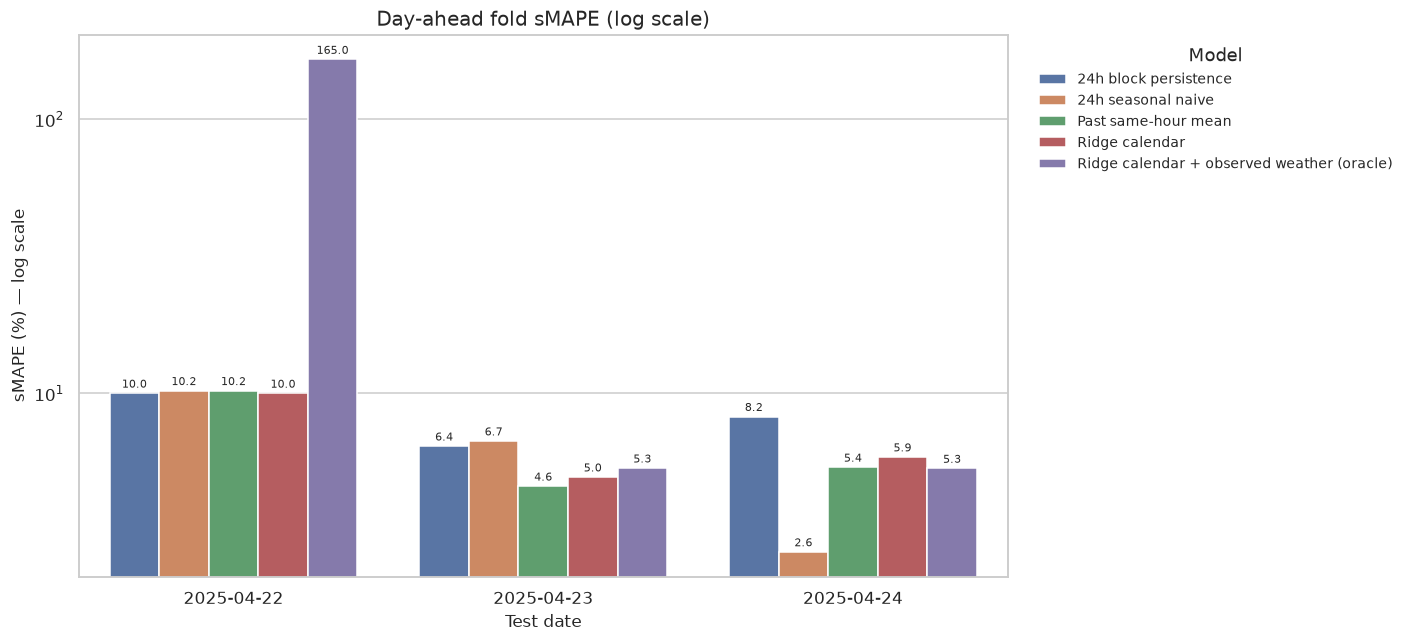

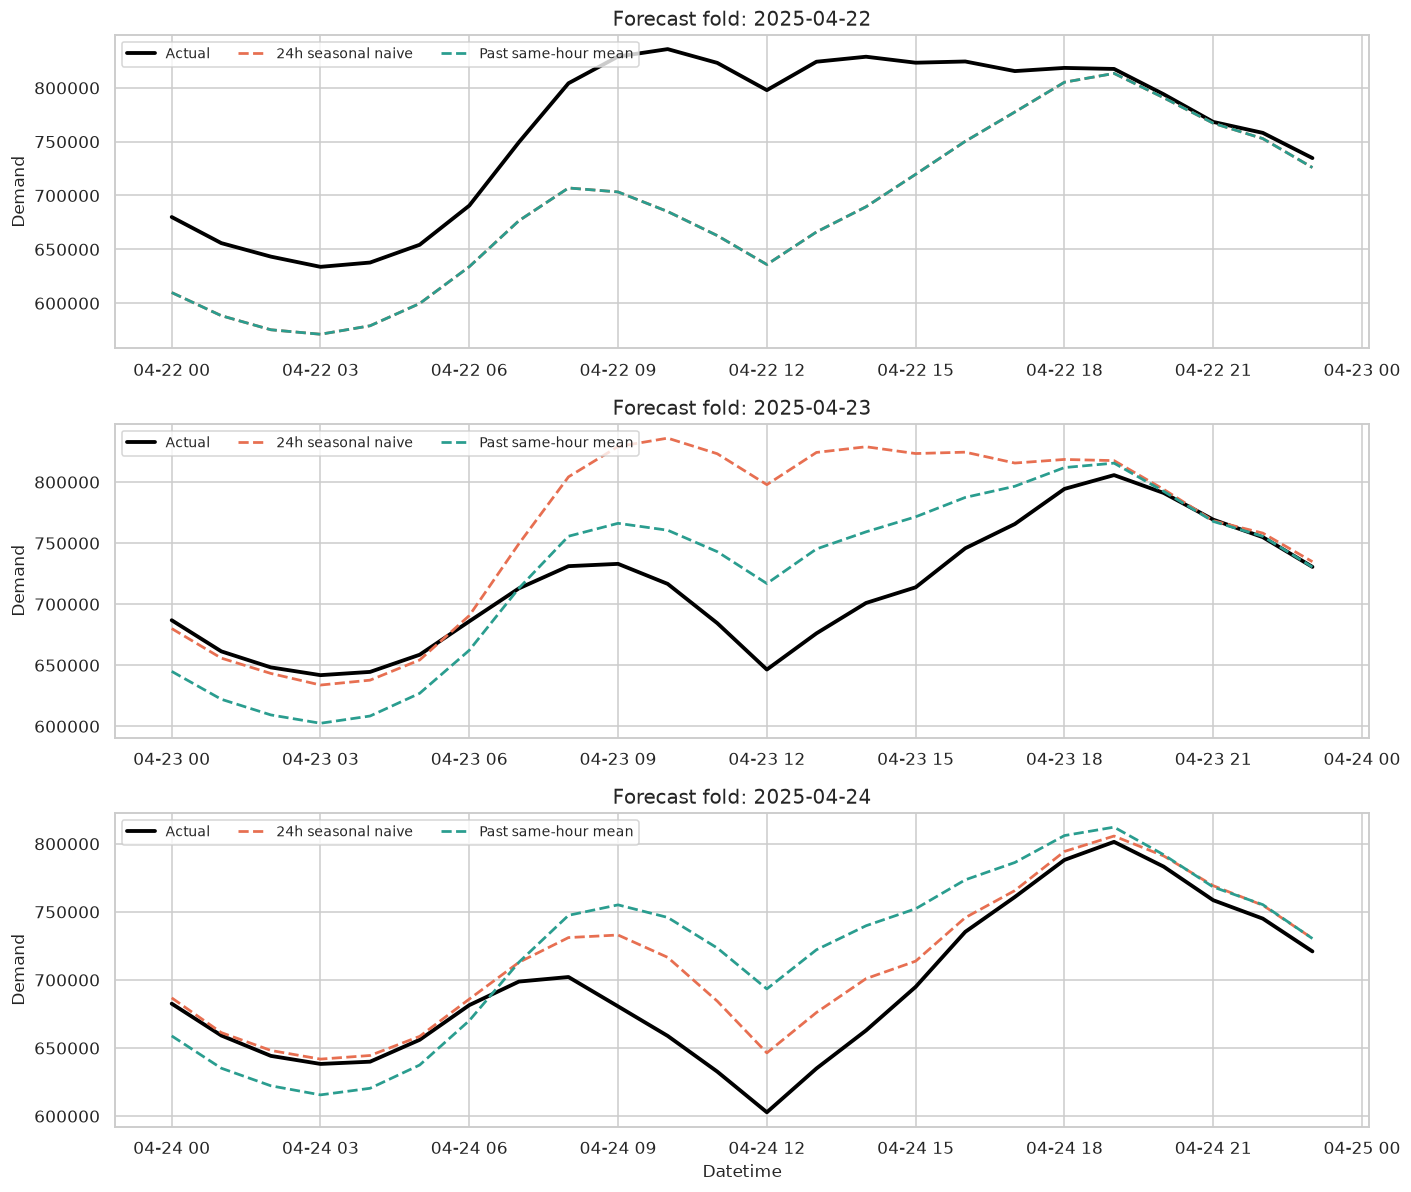

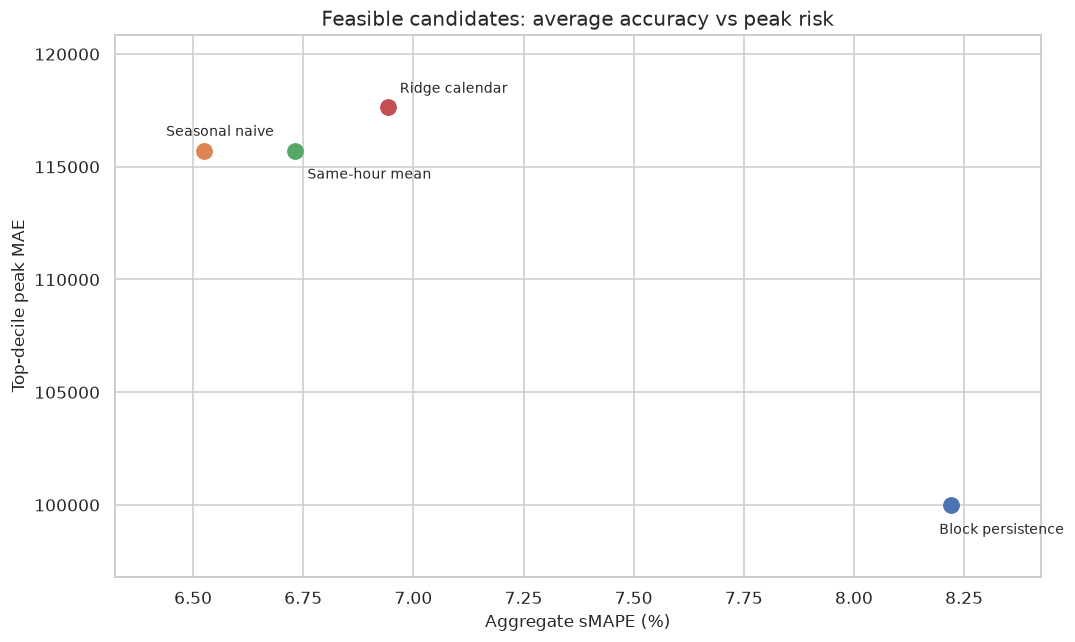

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=backtest_fold_metrics, x="test_date", y="smape_pct", hue="model", ax=ax)
ax.set_yscale("log")
ax.set(title="Day-ahead fold sMAPE (log scale)", xlabel="Test date", ylabel="sMAPE (%) — log scale")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7, padding=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_backtest_fold_smape.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=False)
prediction_models = ["seasonal_naive_24h", "past_same_hour_mean"]
prediction_colors = {"seasonal_naive_24h": "#e76f51", "past_same_hour_mean": "#2a9d8f"}
for ax, (test_date, group) in zip(axes, backtest_predictions.groupby("test_date", sort=True)):
    actual = group[group["model_id"] == prediction_models[0]][["datetime", "actual"]].drop_duplicates()
    ax.plot(actual["datetime"], actual["actual"], color="black", linewidth=2.5, label="Actual")
    for model_id in prediction_models:
        model_group = group[group["model_id"] == model_id]
        ax.plot(
            model_group["datetime"],
            model_group["prediction"],
            linewidth=1.8,
            linestyle="--",
            color=prediction_colors[model_id],
            label=MODEL_LABELS[model_id],
        )
    ax.set(title=f"Forecast fold: {test_date}", ylabel="Demand")
    ax.legend(loc="upper left", ncol=3, frameon=True)
axes[-1].set_xlabel("Datetime")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_backtest_predictions.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
feasible_risk_plot = backtest_aggregate_metrics[
    backtest_aggregate_metrics["model_id"] != "ridge_calendar_weather_oracle"
].copy()
short_labels = {
    "block_persistence_24h": "Block persistence",
    "seasonal_naive_24h": "Seasonal naive",
    "past_same_hour_mean": "Same-hour mean",
    "ridge_calendar": "Ridge calendar",
}
annotation_offsets = {
    "block_persistence_24h": (-8, -19),
    "seasonal_naive_24h": (-25, 10),
    "past_same_hour_mean": (8, -18),
    "ridge_calendar": (8, 9),
}
for _, row in feasible_risk_plot.iterrows():
    ax.scatter(row["smape_pct"], row["peak_mae"], s=100)
    ax.annotate(
        short_labels[row["model_id"]],
        (row["smape_pct"], row["peak_mae"]),
        xytext=annotation_offsets[row["model_id"]],
        textcoords="offset points",
        fontsize=9,
    )
ax.set(
    title="Feasible candidates: average accuracy vs peak risk",
    xlabel="Aggregate sMAPE (%)",
    ylabel="Top-decile peak MAE",
)
ax.margins(x=0.12, y=0.18)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "09_accuracy_peak_tradeoff.png", bbox_inches="tight")
plt.show()

### 결과 해석

- 24시간 계절 나이브는 전체 sMAPE 기준으로 가장 낮더라도 날짜별 결과가 크게 흔들릴 수 있다.
- 마지막 하루만 보면 좋은 결과를 선택적으로 보고하게 되므로 세 fold를 모두 공개해야 한다.
- 관측기상 Ridge는 첫 fold에서 학습범위를 벗어난 강수·습도에 외삽해 음수 수요를 만들 수 있다. 이는 기상이 무가치해서가 아니라 **24시간 학습자료로 기상회귀를 시도한 설계가 불안정**하다는 뜻이다.
- aggregate 평균과 피크 MAE의 순위가 다르면 모델 선택은 하나의 지표만으로 끝낼 수 없다.

## 7. 기상 입력의 범위 이탈과 외삽 스트레스

각 fold에서 test 기상값이 train의 최소–최대 범위를 얼마나 벗어나는지 확인한다. 관측기상을 train 범위로 clipping한 결과도 함께 계산하지만, clipping은 물리적으로 불가능한 음수예측을 줄일 뿐 데이터 부족을 해결하지는 않는다.

In [11]:
range_violation_rows = []
stress_rows = []

for fold_number, origin in enumerate(fold_origins, start=1):
    train = df.iloc[:origin].copy()
    test = df.iloc[origin : origin + 24].copy()
    for feature in WEATHER_COLS:
        train_min = train[feature].min()
        train_max = train[feature].max()
        outside = (test[feature] < train_min) | (test[feature] > train_max)
        range_violation_rows.append(
            {
                "fold": fold_number,
                "test_date": str(test["date"].iloc[0]),
                "feature": feature,
                "train_min": train_min,
                "train_max": train_max,
                "test_min": test[feature].min(),
                "test_max": test[feature].max(),
                "outside_train_range_count": int(outside.sum()),
                "outside_train_range_pct": outside.mean() * 100,
            }
        )

    oracle_model = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=10.0))])
    oracle_model.fit(train[oracle_features], train["demand"])
    raw_prediction = oracle_model.predict(test[oracle_features])
    clipped_test = test.copy()
    for feature in WEATHER_COLS:
        clipped_test[feature] = clipped_test[feature].clip(train[feature].min(), train[feature].max())
    clipped_prediction = oracle_model.predict(clipped_test[oracle_features])

    for variant, prediction in [("raw_oracle", raw_prediction), ("train_range_clipped_oracle", clipped_prediction)]:
        metrics = forecast_metrics(test["demand"], prediction)
        stress_rows.append(
            {
                "fold": fold_number,
                "test_date": str(test["date"].iloc[0]),
                "variant": variant,
                "prediction_min": prediction.min(),
                "prediction_max": prediction.max(),
                **metrics,
            }
        )

feature_range_violations = pd.DataFrame(range_violation_rows)
weather_extrapolation_stress = pd.DataFrame(stress_rows)
feature_range_violations.to_csv(TABLE_DIR / "feature_range_violations.csv", index=False, encoding="utf-8-sig")
weather_extrapolation_stress.to_csv(TABLE_DIR / "weather_extrapolation_stress.csv", index=False, encoding="utf-8-sig")

display(feature_range_violations.round(3))
display(weather_extrapolation_stress[["test_date", "variant", "smape_pct", "prediction_min", "prediction_max", "negative_prediction_count"]].round(3))

,fold,test_date,feature,train_min,train_max,test_min,test_max,outside_train_range_count,outside_train_range_pct
0,1,2025-04-22,temperature,11.86,22.48,14.20,16.50,0,0.000
1,1,2025-04-22,wind_speed,1.22,3.12,1.44,2.45,0,0.000
2,1,2025-04-22,precipitation,0.00,0.01,0.01,2.80,23,95.833
3,1,2025-04-22,humidity,54.30,91.28,85.20,95.50,17,70.833
4,2,2025-04-23,temperature,11.86,22.48,11.31,18.55,3,12.500
5,2,2025-04-23,wind_speed,1.22,3.12,1.26,2.76,0,0.000
6,2,2025-04-23,precipitation,0.00,2.80,0.00,0.03,0,0.000
7,2,2025-04-23,humidity,54.30,95.50,61.78,92.19,0,0.000
8,3,2025-04-24,temperature,11.31,22.48,9.75,19.67,8,33.333
9,3,2025-04-24,wind_speed,1.22,3.12,1.16,3.95,14,58.333


,test_date,variant,smape_pct,prediction_min,prediction_max,negative_prediction_count
0,2025-04-22,raw_oracle,165.004,-1.423846e+07,630034.698,19
1,2025-04-22,train_range_clipped_oracle,19.154,5.789750e+05,671661.746,0
2,2025-04-23,raw_oracle,5.340,6.338515e+05,747603.761,0
3,2025-04-23,train_range_clipped_oracle,5.307,6.357778e+05,747603.761,0
4,2025-04-24,raw_oracle,5.327,6.494149e+05,747584.077,0
5,2025-04-24,train_range_clipped_oracle,5.173,6.484949e+05,751497.524,0


## 8. 임시 의사결정 매트릭스와 가중치 민감도

이 절은 4일 표본으로 최종 모델을 승인하기 위한 것이 아니라, **같은 결과라도 판단기준에 따라 선택이 달라지는지** 보여주는 진단이다.

### 하드 게이트

- 실제 미래 관측기상을 요구하거나 음수 수요를 생성한 모델은 SAW 대상에서 제외한다.

### 기본 가중치

| 기준 | 가중치 | 방향 |
|---|---:|---|
| 전체 sMAPE | 35% | 낮을수록 좋음 |
| fold sMAPE 범위 | 25% | 낮을수록 안정적 |
| 상위 10% 피크 MAE | 20% | 낮을수록 좋음 |
| 절대 편향 | 10% | 낮을수록 좋음 |
| 단순성 | 10% | 높을수록 좋음 |

각 수치기준을 후보 내 0–1 min-max 효용점수로 바꾸고 가중합한다. 단순성은 재현 가능한 명시적 규칙으로 `block=1.00`, `seasonal=1.00`, `same-hour=0.95`, `Ridge=0.80`을 사용한다.

In [12]:
eligible_model_ids = [
    "block_persistence_24h",
    "seasonal_naive_24h",
    "past_same_hour_mean",
    "ridge_calendar",
]
simplicity_scores = {
    "block_persistence_24h": 1.00,
    "seasonal_naive_24h": 1.00,
    "past_same_hour_mean": 0.95,
    "ridge_calendar": 0.80,
}

decision_matrix = backtest_aggregate_metrics[
    backtest_aggregate_metrics["model_id"].isin(eligible_model_ids)
][
    ["model_id", "model", "smape_pct", "fold_smape_range_pct_points", "peak_mae", "bias_prediction_minus_actual"]
].copy()
decision_matrix["abs_bias"] = decision_matrix["bias_prediction_minus_actual"].abs()
decision_matrix["simplicity_score"] = decision_matrix["model_id"].map(simplicity_scores)


def lower_is_better_score(series: pd.Series) -> pd.Series:
    minimum, maximum = series.min(), series.max()
    if np.isclose(minimum, maximum):
        return pd.Series(1.0, index=series.index)
    return 1 - (series - minimum) / (maximum - minimum)


decision_matrix["accuracy_score"] = lower_is_better_score(decision_matrix["smape_pct"])
decision_matrix["stability_score"] = lower_is_better_score(decision_matrix["fold_smape_range_pct_points"])
decision_matrix["peak_risk_score"] = lower_is_better_score(decision_matrix["peak_mae"])
decision_matrix["bias_score"] = lower_is_better_score(decision_matrix["abs_bias"])

scenario_weights = {
    "balanced": {"accuracy_score": 0.35, "stability_score": 0.25, "peak_risk_score": 0.20, "bias_score": 0.10, "simplicity_score": 0.10},
    "accuracy_first": {"accuracy_score": 0.60, "stability_score": 0.10, "peak_risk_score": 0.15, "bias_score": 0.10, "simplicity_score": 0.05},
    "stability_first": {"accuracy_score": 0.20, "stability_score": 0.50, "peak_risk_score": 0.15, "bias_score": 0.05, "simplicity_score": 0.10},
    "peak_first": {"accuracy_score": 0.25, "stability_score": 0.15, "peak_risk_score": 0.45, "bias_score": 0.05, "simplicity_score": 0.10},
}

scenario_rows = []
for scenario, weights in scenario_weights.items():
    decision_matrix[scenario] = sum(decision_matrix[criterion] * weight for criterion, weight in weights.items())
    ranks = decision_matrix[scenario].rank(ascending=False, method="min").astype(int)
    for idx, row in decision_matrix.iterrows():
        scenario_rows.append(
            {
                "scenario": scenario,
                "model_id": row["model_id"],
                "model": row["model"],
                "saw_score": row[scenario],
                "rank": int(ranks.loc[idx]),
            }
        )
decision_scenarios = pd.DataFrame(scenario_rows)

criteria_order = ["accuracy_score", "stability_score", "peak_risk_score", "bias_score", "simplicity_score"]
base_weights = np.array([scenario_weights["balanced"][criterion] for criterion in criteria_order])
weight_draws = rng.dirichlet(base_weights * 5, size=10_000)
utility_matrix = decision_matrix[criteria_order].to_numpy()
simulated_scores = weight_draws @ utility_matrix.T
top_indices = simulated_scores.argmax(axis=1)
top_rank_probability = (
    pd.Series(decision_matrix.iloc[top_indices]["model_id"].to_numpy())
    .value_counts(normalize=True)
    .rename_axis("model_id")
    .reset_index(name="top_rank_probability")
)
top_rank_probability = decision_matrix[["model_id", "model"]].merge(top_rank_probability, on="model_id", how="left").fillna({"top_rank_probability": 0})
top_rank_probability["top_rank_probability_pct"] = top_rank_probability["top_rank_probability"] * 100

decision_matrix.to_csv(TABLE_DIR / "model_decision_matrix.csv", index=False, encoding="utf-8-sig")
decision_scenarios.to_csv(TABLE_DIR / "model_decision_scenarios.csv", index=False, encoding="utf-8-sig")
top_rank_probability.to_csv(TABLE_DIR / "model_weight_sensitivity.csv", index=False, encoding="utf-8-sig")

display(decision_matrix[["model", "smape_pct", "fold_smape_range_pct_points", "peak_mae", "abs_bias", "balanced", "accuracy_first", "stability_first", "peak_first"]].round(3))
display(decision_scenarios.sort_values(["scenario", "rank"]).round(3))
display(top_rank_probability.sort_values("top_rank_probability_pct", ascending=False).round(3))

,model,smape_pct,fold_smape_range_pct_points,peak_mae,abs_bias,balanced,accuracy_first,stability_first,peak_first
0,24h block persistence,8.221,3.590,100004.000,8099.333,0.592,0.342,0.771,0.721
1,24h seasonal naive,6.525,7.586,115693.500,2464.083,0.572,0.767,0.367,0.450
2,Past same-hour mean,6.732,5.643,115693.500,12205.424,0.546,0.640,0.531,0.438
3,Ridge calendar,6.941,5.051,117671.173,12205.424,0.503,0.556,0.548,0.364


,scenario,model_id,model,saw_score,rank
5,accuracy_first,seasonal_naive_24h,24h seasonal naive,0.767,1
6,accuracy_first,past_same_hour_mean,Past same-hour mean,0.640,2
7,accuracy_first,ridge_calendar,Ridge calendar,0.556,3
4,accuracy_first,block_persistence_24h,24h block persistence,0.342,4
0,balanced,block_persistence_24h,24h block persistence,0.592,1
1,balanced,seasonal_naive_24h,24h seasonal naive,0.572,2
2,balanced,past_same_hour_mean,Past same-hour mean,0.546,3
3,balanced,ridge_calendar,Ridge calendar,0.503,4
12,peak_first,block_persistence_24h,24h block persistence,0.721,1
13,peak_first,seasonal_naive_24h,24h seasonal naive,0.450,2


,model_id,model,top_rank_probability,top_rank_probability_pct
0,block_persistence_24h,24h block persistence,0.482,48.19
1,seasonal_naive_24h,24h seasonal naive,0.384,38.43
2,past_same_hour_mean,Past same-hour mean,0.114,11.45
3,ridge_calendar,Ridge calendar,0.019,1.93


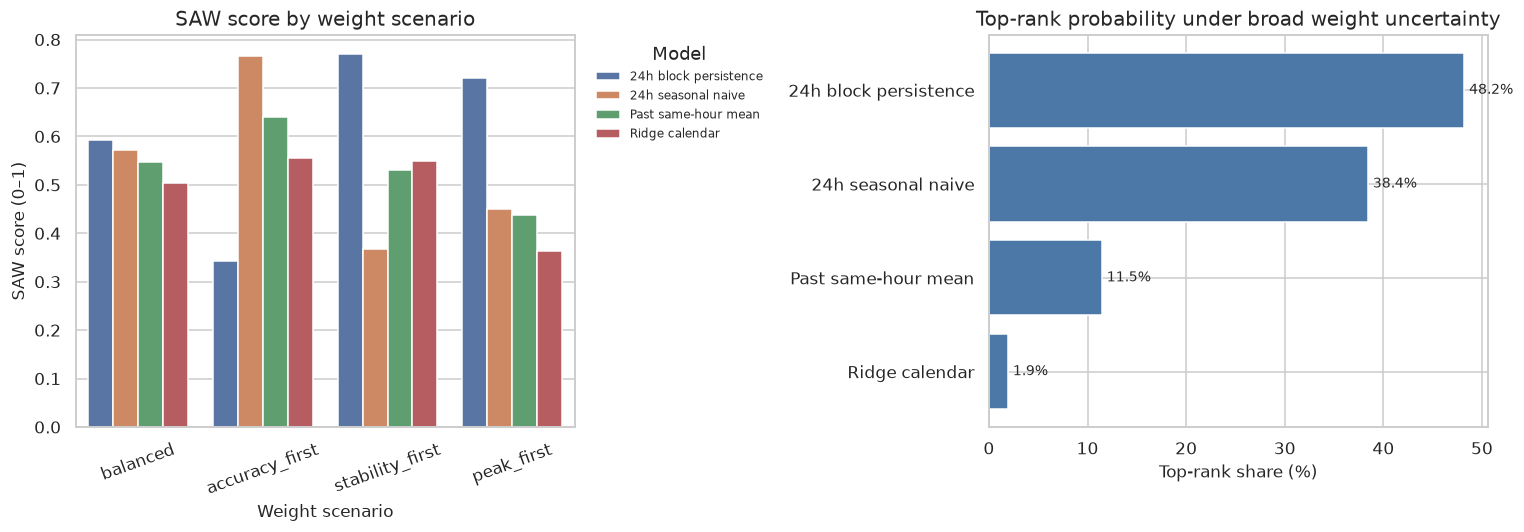

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=decision_scenarios, x="scenario", y="saw_score", hue="model", ax=axes[0])
axes[0].set(title="SAW score by weight scenario", xlabel="Weight scenario", ylabel="SAW score (0–1)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

ordered_probability = top_rank_probability.sort_values("top_rank_probability_pct", ascending=True)
axes[1].barh(ordered_probability["model"], ordered_probability["top_rank_probability_pct"], color="#4c78a8")
axes[1].set(title="Top-rank probability under broad weight uncertainty", xlabel="Top-rank share (%)", ylabel="")
for y_pos, value in enumerate(ordered_probability["top_rank_probability_pct"]):
    axes[1].text(value + 0.5, y_pos, f"{value:.1f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "10_decision_weight_sensitivity.png", bbox_inches="tight")
plt.show()

### 의사결정 해석

- 정확도만 우선하면 계절 나이브가 유리할 수 있지만, fold 안정성·피크오차에 더 큰 비중을 주면 24시간 block persistence가 앞설 수 있다.
- Monte Carlo 가중치 민감도에서 1위 확률이 한 모델에 압도적으로 모이지 않으면 현재 증거로 선택이 강건하지 않다.
- 이 SAW는 **모델 승인표가 아니라 판단 흔들림을 드러내는 표**다. 4일 표본의 min-max 점수는 전체 데이터가 들어오면 크게 바뀔 수 있다.

## 9. 원본 코드와 재현성 감사

원본 전처리 Python 파일과 `train.ipynb`는 전체 데이터가 복구되기 전까지 실행 파이프라인으로 합치지 않는다. 아래 표는 새 노트북이 해결한 항목과 여전히 외부 자료가 필요한 항목을 구분한다.

In [14]:
source_code_audit = pd.DataFrame(
    [
        ["패키지 데이터", "sample_data.csv와 팀 폴더 data.csv가 바이트 단위로 동일한 96시간 복제본", "Critical", "전체 원천·중간·merged 데이터와 체크섬 제공"],
        ["reproduce_analysis.py", "단일 마지막 날만 평가하고 1-step과 day-ahead 조건을 한 표에 혼합", "High", "이 노트북의 3-fold 24h day-ahead 표로 대체"],
        ["reproduce_analysis.py", "체크인된 표·그림 전체를 실제로 재생성하지 못함", "High", "analysis_outputs의 모든 표·그림을 본 노트북에서 생성"],
        ["KPX 단위시간 변경.py", "문자열 연결로 total을 만들지만 결과행에 저장하지 않아 집계가 반영되지 않음", "Critical", "수치형 resample과 총량보존 테스트로 재작성"],
        ["가중합.py", "기상 결측을 0으로 치환하고 미매칭 관측소를 조용히 제외", "High", "원시 결측률·대체로그·매칭률·민감도 보고"],
        ["가중합.py", "복수 관측소 지역에 지역 전체 가중치를 반복 적용할 위험", "High", "행정코드 기반 조인과 관측소 내 가중치 재배분"],
        ["train.ipynb", "merged data.csv와 best2.json이 없고 실행순서가 뒤섞이며 GridSearch가 중단됨", "Critical", "빈 커널 Run All·고정 seed·환경 버전·완전한 데이터 제공"],
        ["train.ipynb", "2025 validation을 튜닝·선택·평가에 재사용하고 독립 test가 없음", "High", "개발 rolling-origin과 완전 격리 final test"],
        ["train.ipynb", "day-ahead에서 당일 실제 lag-1/rolling과 실제 미래 관측기상을 사용할 위험", "Critical", "발행시각 기준 feature contract와 예보기상 vintage 사용"],
        ["표적 정의", "demand 단위·배율·발전단/판매단 의미가 패키지에서 확정되지 않음", "High", "원천행→변환→merged 값 lineage 테스트"],
    ],
    columns=["area", "finding", "severity", "required_action"],
)

missing_required_files = pd.DataFrame(
    {
        "referenced_but_missing": [
            "../data/kpx/kpx_data.csv",
            "../data/AWS/인구 가중치.csv",
            "../data/AWS/태양광 가중치.csv",
            "merged data.csv",
            "best2.json",
            "KOSIS 원시파일 일체",
            "AWS 원시파일 일체",
            "KPX 원시파일 일체",
        ]
    }
)

source_code_audit.to_csv(TABLE_DIR / "source_code_audit.csv", index=False, encoding="utf-8-sig")
missing_required_files.to_csv(TABLE_DIR / "missing_required_files.csv", index=False, encoding="utf-8-sig")
display(source_code_audit)
display(missing_required_files)

,area,finding,severity,required_action
0,패키지 데이터,sample_data.csv와 팀 폴더 data.csv가 바이트 단위로 동일한 96...,Critical,전체 원천·중간·merged 데이터와 체크섬 제공
1,reproduce_analysis.py,단일 마지막 날만 평가하고 1-step과 day-ahead 조건을 한 표에 혼합,High,이 노트북의 3-fold 24h day-ahead 표로 대체
2,reproduce_analysis.py,체크인된 표·그림 전체를 실제로 재생성하지 못함,High,analysis_outputs의 모든 표·그림을 본 노트북에서 생성
3,KPX 단위시간 변경.py,문자열 연결로 total을 만들지만 결과행에 저장하지 않아 집계가 반영되지 않음,Critical,수치형 resample과 총량보존 테스트로 재작성
4,가중합.py,기상 결측을 0으로 치환하고 미매칭 관측소를 조용히 제외,High,원시 결측률·대체로그·매칭률·민감도 보고
5,가중합.py,복수 관측소 지역에 지역 전체 가중치를 반복 적용할 위험,High,행정코드 기반 조인과 관측소 내 가중치 재배분
6,train.ipynb,merged data.csv와 best2.json이 없고 실행순서가 뒤섞이며 Gri...,Critical,빈 커널 Run All·고정 seed·환경 버전·완전한 데이터 제공
7,train.ipynb,2025 validation을 튜닝·선택·평가에 재사용하고 독립 test가 없음,High,개발 rolling-origin과 완전 격리 final test
8,train.ipynb,day-ahead에서 당일 실제 lag-1/rolling과 실제 미래 관측기상을 사...,Critical,발행시각 기준 feature contract와 예보기상 vintage 사용
9,표적 정의,demand 단위·배율·발전단/판매단 의미가 패키지에서 확정되지 않음,High,원천행→변환→merged 값 lineage 테스트


,referenced_but_missing
0,../data/kpx/kpx_data.csv
1,../data/AWS/인구 가중치.csv
2,../data/AWS/태양광 가중치.csv
3,merged data.csv
4,best2.json
5,KOSIS 원시파일 일체
6,AWS 원시파일 일체
7,KPX 원시파일 일체


## 10. 결론과 다음 분석 조건

### 이 노트북에서 재현된 것

- 패키지 샘플의 파일 지문, 96시간 연속성, 최종 파일 수준의 결측·중복·범위 검사
- 날짜·시간대 부하 패턴, 분포, 피크, 램프, 자기상관
- 기상관계의 원상관과 교란 민감도
- 가능한 세 날짜의 동일 24시간 day-ahead 백테스트
- 평균 정확도, 피크위험, 편향, 안정성 사이의 임시 SAW와 가중치 민감도

### 재현되지 않은 것

- 전체 기간 XGBoost 성능, SHAP 결과, 원시자료부터 merged 데이터까지의 변환 정확성
- 수요의 공식 단위·배율, 실제 예보기상 기반 운영 성능, 계절·휴일·폭염·한파 성능
- 충분한 test 기간을 요구하는 block bootstrap 신뢰구간, Diebold–Mariano 검정, 비용편익 금액

### 다음 단계 승인 조건

1. 최소 2년 이상의 시간당 수요·달력·예보 기상 vintage를 확보한다.
2. 원천 파일과 모든 변환 산출물에 SHA-256, 스키마, 단위, 시간대, 접근일을 기록한다.
3. 발행시각 이전 정보만 쓰는 feature contract를 테스트한다.
4. lag-24, lag-168, 동일요일·시간 평균을 필수 기준선으로 둔다.
5. 개발기간 rolling-origin 튜닝 후 마지막 6~12개월을 한 번만 여는 final test를 둔다.
6. 전체·피크·휴일·기상극단 subgroup과 예측구간 coverage를 함께 평가한다.
7. 모델 채택은 기준선 대비 개선, 통계적 불확실성, 피크 guardrail, 운영비용을 모두 통과할 때만 결정한다.

In [15]:
seasonal_aggregate = backtest_aggregate_metrics.loc[
    backtest_aggregate_metrics["model_id"] == "seasonal_naive_24h"
].iloc[0]
seasonal_folds = backtest_fold_metrics.loc[
    backtest_fold_metrics["model_id"] == "seasonal_naive_24h", ["test_date", "smape_pct"]
].sort_values("test_date")
best_fold = seasonal_folds.loc[seasonal_folds["smape_pct"].idxmin()]
worst_fold = seasonal_folds.loc[seasonal_folds["smape_pct"].idxmax()]
oracle_aggregate = backtest_aggregate_metrics.loc[
    backtest_aggregate_metrics["model_id"] == "ridge_calendar_weather_oracle"
].iloc[0]
same_hour_peak = int(hourly_profile.loc[hourly_profile["mean"].idxmax(), "hour"])
same_hour_trough = int(hourly_profile.loc[hourly_profile["mean"].idxmin(), "hour"])

display(
    Markdown(
        f'''
### 실행 요약

- 데이터: **{len(df)}시간**, {df['datetime'].min()} ~ {df['datetime'].max()}, SHA-256 `{sha256_file(DATA_PATH)}`
- 시간대 평균수요: **{same_hour_trough:02d}시 최저 {hourly_profile['mean'].min():,.0f}**, **{same_hour_peak:02d}시 최고 {hourly_profile['mean'].max():,.0f}**
- 강수 집중: 총 강수의 **{max_day_precipitation_share:.2f}%**가 강수 최대 하루에 집중
- 24h seasonal naive 3-fold 전체: **MAE {seasonal_aggregate['mae']:,.0f}, sMAPE {seasonal_aggregate['smape_pct']:.2f}%**
- fold sMAPE: 최저 **{best_fold['smape_pct']:.2f}% ({best_fold['test_date']})**, 최고 **{worst_fold['smape_pct']:.2f}% ({worst_fold['test_date']})**
- 관측기상 oracle Ridge: 전체 **sMAPE {oracle_aggregate['smape_pct']:.2f}%**, 음수예측 **{int(oracle_aggregate['negative_prediction_count'])}건**

**판정:** 현재 결과는 단순 기준선을 운영모델로 승인하는 근거가 아니라, 전체 데이터 복구와 누수 없는 재검증을 우선해야 한다는 진단 근거다.
'''
    )
)


### 실행 요약

- 데이터: **96시간**, 2025-04-21 00:00:00 ~ 2025-04-24 23:00:00, SHA-256 `fb214f92f1ea57ff0f5ce5f64f6be61ee139f2d89f1041fff1a4f3b47f3b82a4`
- 시간대 평균수요: **03시 최저 621,251**, **19시 최고 809,492**
- 강수 집중: 총 강수의 **99.49%**가 강수 최대 하루에 집중
- 24h seasonal naive 3-fold 전체: **MAE 47,364, sMAPE 6.53%**
- fold sMAPE: 최저 **2.64% (2025-04-24)**, 최고 **10.23% (2025-04-22)**
- 관측기상 oracle Ridge: 전체 **sMAPE 58.56%**, 음수예측 **19건**

**판정:** 현재 결과는 단순 기준선을 운영모델로 승인하는 근거가 아니라, 전체 데이터 복구와 누수 없는 재검증을 우선해야 한다는 진단 근거다.
